                            
                       Electrical Grid Stability Simulated Data
            


Student ID : 226120L

Student Name : Thilakarathna I.I.S.

# 1.  **Problem Definition**

**Objective:**

To develop a model that classifies whether the system is in a stable or unstable state. This model could help grid operators take preventive actions in unstable conditions, improving grid reliability and reducing the risk of blackouts.

**Business Problem :**

"Can the stability of a decentralized smart grid system be accurately predicted based on the reaction times, power consumption, and price elasticity of the nodes?"

**Loading the dataset**

In [ ]:
import pandas as pd

file_path = '/content/Data_for_UCI_named.csv'
Elec_data = pd.read_csv(file_path)

target_variable = 'stabf'  #  stable or unstable
non_predictive = ['p1', 'stab', 'stabf']  # Exclude non-predictive columns and target
features = [col for col in Elec_data.columns if col not in non_predictive]

print("Target Variable:", target_variable)
print("Features:", features)







Target Variable: stabf
Features: ['tau1', 'tau2', 'tau3', 'tau4', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']


**Interpretation**

Target Variable (stabf) -

 This categorical variable indicates whether the grid system is stable ("stable") or unstable ("unstable").

Features-

*   Reaction times (tau1, tau2, tau3, tau4)
 These values may indicate how quickly each node reacts to changes in the grid, which could affect system stability.
*   Nominal power values (p2, p3, p4)
These represent power consumption/production, where positive values indicate production and negative values indicate consumption. Variations here might influence the grid's balance.  
*  Price elasticity coefficients (g1, g2, g3, g4)
These might reveal how sensitive each node is to price changes, which could correlate with grid stability under fluctuating demand.








# **2. Data Exploration and Preprocessing**

In this task ,
1. Check for data types and basic statistics.

2. Basic identification of potential outliers.
   
3. Scale continuous features for improved model performance.

4. Convert categorical labels in stabf to numeric format.





Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB

Basic Statistics:
               tau1          tau2          tau3          tau4            p1  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       5.250000      5.250001      5.250004      5.2

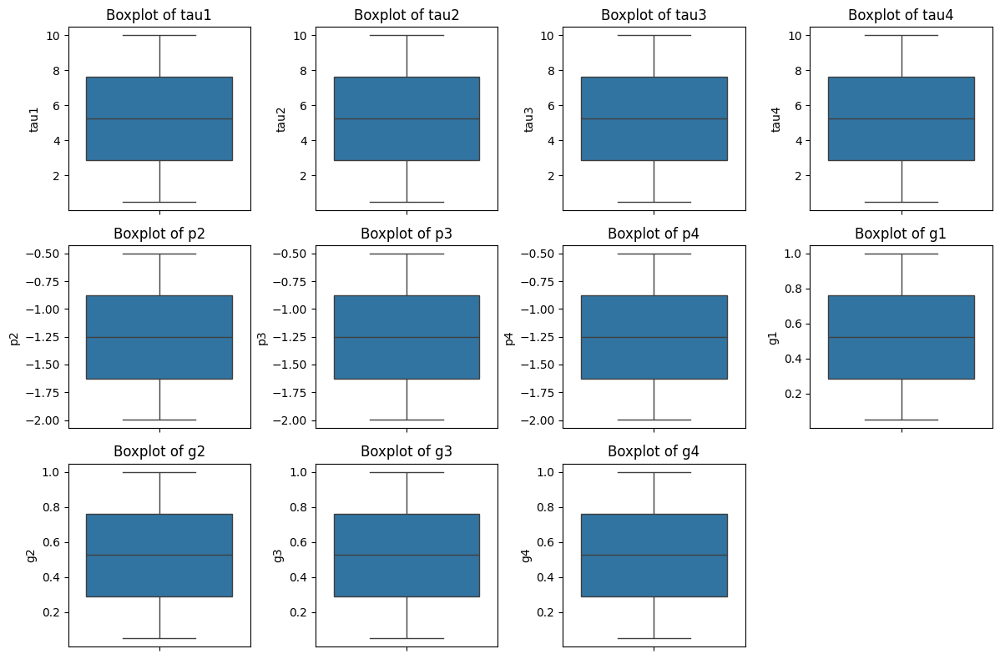

       tau1      tau2      tau3      tau4        p1        p2        p3  \
0  2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1  9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2  8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3  0.716415  7.669600  4.486641  2.340563  3.963791 -1.027473 -1.938944   
4  3.134112  7.608772  4.943759  9.857573  3.525811 -1.125531 -1.845975   

         p4        g1        g2        g3        g4      stab  stabf  
0 -1.723086  0.650456  0.859578  0.887445  0.958034  0.055347      1  
1 -1.255012  0.413441  0.862414  0.562139  0.781760 -0.005957      0  
2 -0.920492  0.163041  0.766689  0.839444  0.109853  0.003471      1  
3 -0.997374  0.446209  0.976744  0.929381  0.362718  0.028871      1  
4 -0.554305  0.797110  0.455450  0.656947  0.820923  0.049860      1  

Encoded Target Variable:
stabf
1    6380
0    3620
Name: count, dtype: int64

Scaled Features:
       tau1      tau2      

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt


print("Dataset Info:")
Elec_data.info()
print("\nBasic Statistics:")
print(Elec_data.describe())

# Plot distributions of numerical features
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(data=Elec_data, y=feature)
    plt.title(f'Boxplot of {feature}')
plt.tight_layout()
plt.show()

# Encoding the target variable 'stabf'
label_encoder = LabelEncoder()
Elec_data['stabf'] = label_encoder.fit_transform(Elec_data['stabf'])  # "stable" = 0, "unstable" = 1
print (Elec_data.head())
print("\nEncoded Target Variable:")
print(Elec_data['stabf'].value_counts())

# Scaling numerical features
scaler = StandardScaler()
Elec_data[features] = scaler.fit_transform(Elec_data[features])
print("\nScaled Features:")
print(Elec_data[features].head())


- There are no missing values.
- According to box plots for each features, there are no potential outliers.
- The **stabf** variable, initially categorical with values "**stable**" and "**unstable**," was encoded to numerical values (0 = stable, 1 = unstable)(**Target Encoding**)
- Some features, such as **p1** (a non-predictive feature linked to the power balance among nodes) and **stab** (a continuous stability measure not intended as a predictor in classification), were excluded from the predictive model (**Feature Exclusion**).
-Scaling was done using StandardScaler, which standardizes each feature to have a mean of 0 and a standard deviation of 1 (Feature Scaling).
-An exploration of the **stabf class distribution** showed that 63.8% of the data points are labeled as unstable, with the remaining 36.2% as stable. While the imbalance is not extreme, it could still influence the model’s accuracy. For instance, a model could theoretically achieve reasonable accuracy by favoring the "unstable" class. Consequently, this imbalance will need to be addressed in model training and evaluation to ensure that both classes are accurately represented.

# **3. Explonatory Data Analysis**

In this task ,  

1.   Visualizing Feature Distributions to to see the distribution shape,skewness, and potential need for transformation (e.g., logarithmic) to normalize features.

2.  The pairwise plot shows interactions between features while coloring points by stability class (0 = stable, 1 = unstable).

2. Correlation Heatmap reveals linear relationships between features.  This identifies any high correlations among features. Strong correlations suggest multicollinearity, which might affect model interpretability.

3.   A count plot of the target variable shows whether the dataset is balanced or imbalanced, essential for model evaluation.

2.   Box plots for each feature segmented by stability class (stabf) help identify which features show significant differences between stable and unstable instances.

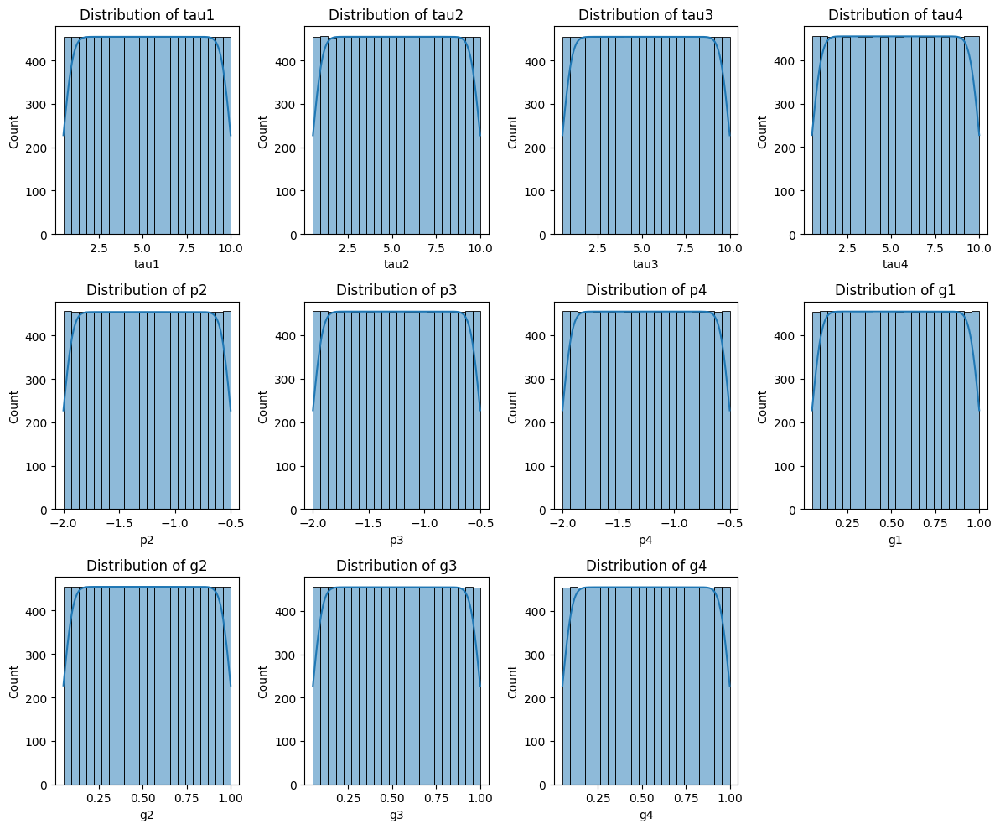

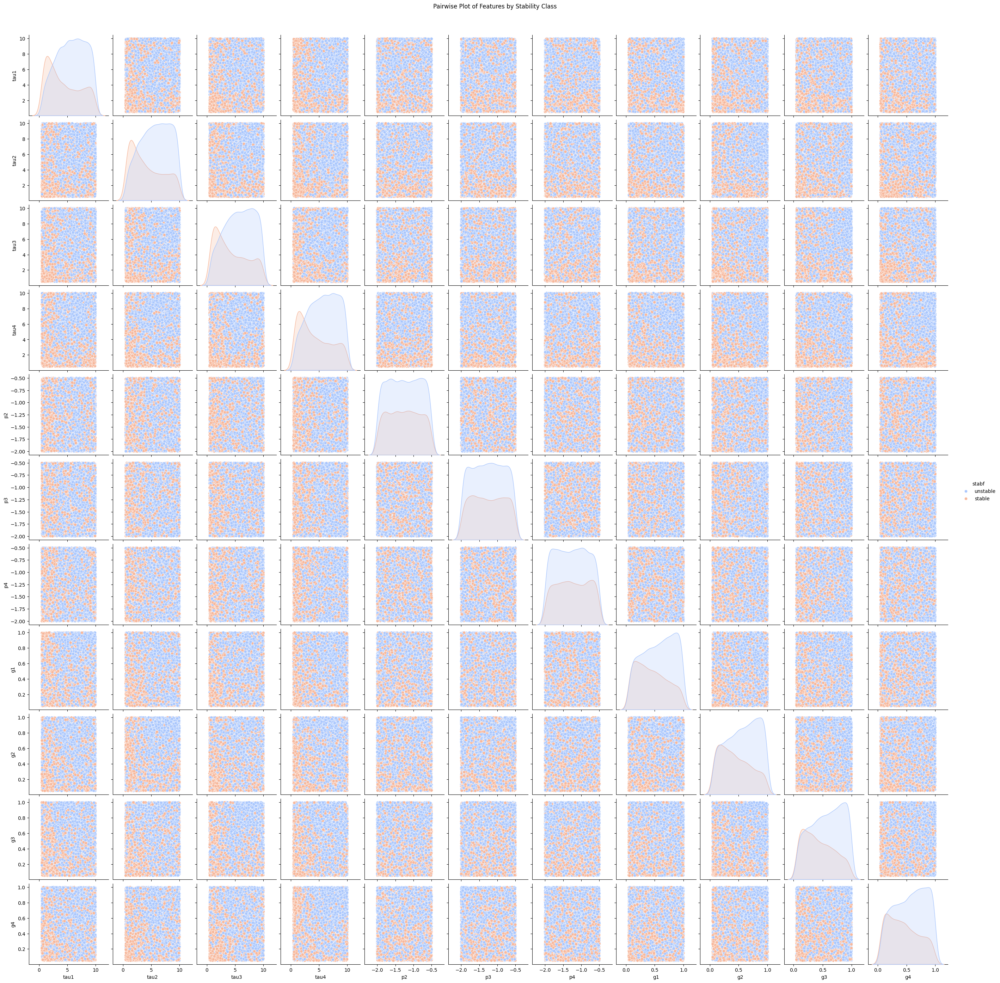

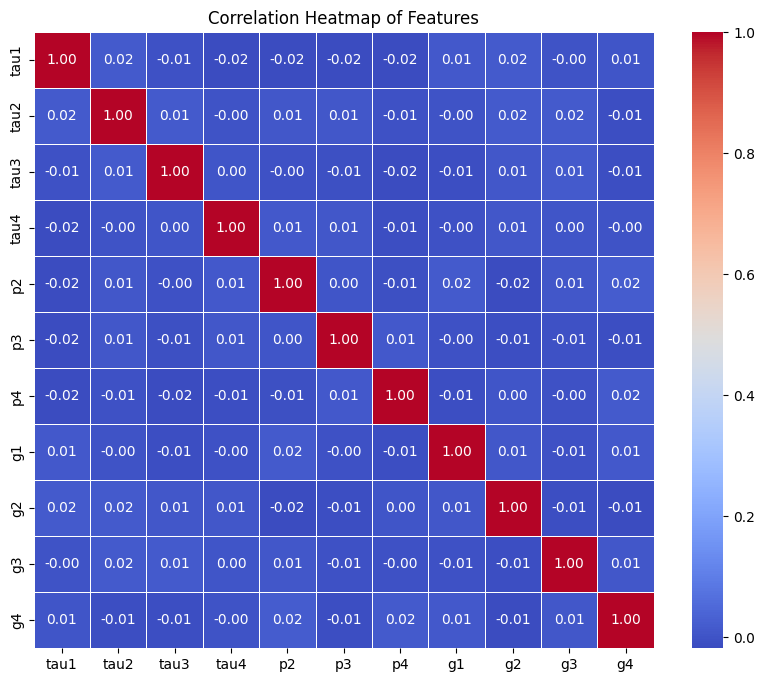

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#  Visualize feature distributions
plt.figure(figsize=(12, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 4, i)
    sns.histplot(Elec_data[feature], kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

#  Pairwise plot for all features
sns.pairplot(Elec_data[features + [target_variable]], hue=target_variable, palette="coolwarm")
plt.suptitle("Pairwise Plot of Features by Stability Class", y=1.02)
plt.show()

#  Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = Elec_data[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()






**Interpretation**

- Reaction times (tau1 to tau4) appear normally distributed with minor skewness.
  Power values (p2, p3, p4) show distributions skewed towards negative values,  Price elasticity coefficients (g1 to g4) display a relatively even distribution within the range [0.05, 1].

- Some features show clear separation between stable and unstable instances,  suggesting they are predictive of grid stability.For example, certain combinations of reaction times and power values seem to exhibit distinct clusters for stable vs. unstable systems.

- There are moderate to low correlations between some reaction times (tau1 to
  tau4), which may indicate similar reaction patterns across nodes.
  power values (p2, p3, p4) show minimal correlation with other features, while price elasticity coefficients (g1 to g4) are relatively independent.



Class Distribution:
           count
stabf          
unstable   6380
stable     3620


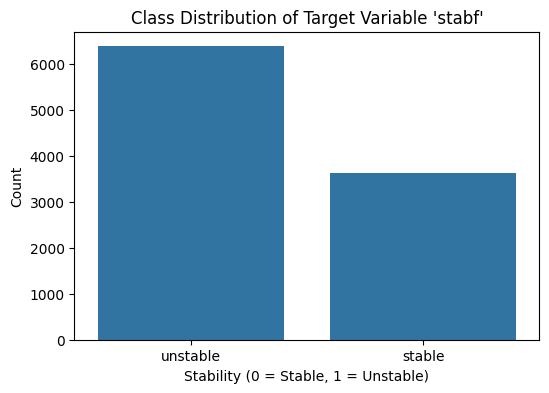

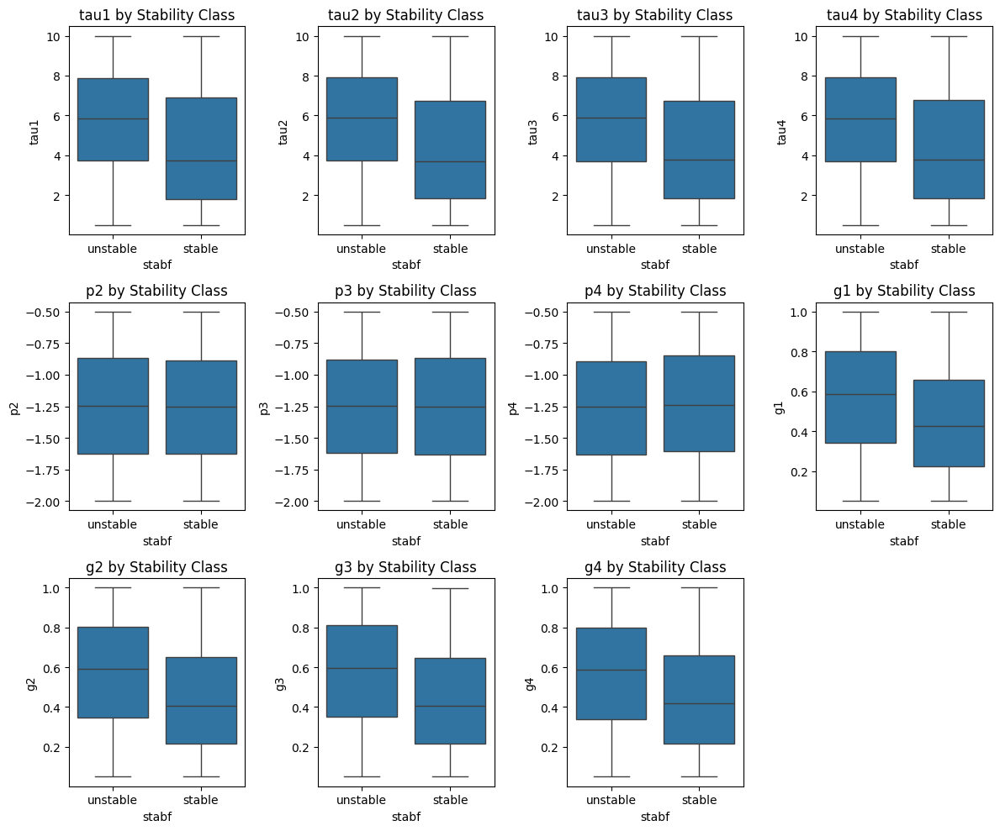

In [ ]:
#  Check for imbalance in target classes
class_distribution = Elec_data['stabf'].value_counts().to_frame(name='count')
print("Class Distribution:\n", class_distribution)

plt.figure(figsize=(6, 4))
sns.countplot(x='stabf', data=Elec_data)
plt.title("Class Distribution of Target Variable 'stabf'")
plt.xlabel("Stability (0 = Stable, 1 = Unstable)")
plt.ylabel("Count")
plt.show()

#  Feature comparisons by stability class
plt.figure(figsize=(12, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x='stabf', y=feature, data=Elec_data)
    plt.title(f'{feature} by Stability Class')
plt.tight_layout()
plt.show()

- The target variable is moderately imbalanced with 63.8% of instances labeled
   as "unstable" and 36.2% as "stable."

- In reaction times and power values, show distinct differences between stable
  and unstable classes. For instance, unstable instances tend to have higher values in specific reaction times. Price elasticity coefficients also exhibit variability by stability class, although the differences are less pronounced

# **4. Model Selection**

In this task ,

1.   Apply SMOTE to Balance the Dataset.

2.   Define X (features) and y (target variable) from the balanced dataset.
3. Split the data into training and test sets with a 70-30 split to prepare for model training and evaluation.
4.   Select Classification Algorithms. They are ,
                  Logistic Regression
                  Decision Tree
                  Random Forest
                  Support Vector Machine (SVM)
5.   Fit each model on the balanced dataset.
6.   Train a Logistic Regression model as a baseline to assess initial model performance and print the baseline model’s accuracy on the test set, providing a reference for comparing the performance of other models.







In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score

X = Elec_data[features]
y = Elec_data[target_variable]

#  Split data into training and test sets (70-30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#  Apply SMOTE only to the training set to balance classes
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Balanced Class Distribution (Training Set):\n", y_train_balanced.value_counts())

#  Model Selection - Define and initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

#  Train and evaluate the baseline model (Logistic Regression)
baseline_model = LogisticRegression()
baseline_model.fit(X_train_balanced, y_train_balanced)
y_pred_baseline = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print("Baseline Accuracy (Logistic Regression): {:.2f}%".format(baseline_accuracy * 100))



Balanced Class Distribution (Training Set):
 stabf
unstable    4466
stable      4466
Name: count, dtype: int64
Baseline Accuracy (Logistic Regression): 80.43%


**Interpretation**

- Logistic Regression -  A simple, linear model that serves as a baseline for comparison.
- Decision Tree -  An interpretable model that can capture non-linear relationships and provides insights into feature importance.
- Random Forest -  An ensemble model based on multiple decision trees, offering robustness against overfitting and improved predictive power.
- Support Vector Machine (SVM) - A powerful classifier suitable for high-dimensional data, which can handle non-linear relationships.

--The SMOTE application successfully balanced the training set to 4,466 instances each for the stable and unstable classes. This ensures equal representation, preventing the model from being biased toward the previously larger unstable class.


--The **baseline accuracy of logistic regression** on the test set is approximately 80.4%.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Support Vector Machine": SVC(class_weight='balanced', probability=True, random_state=42)
}

# Train each model on the SMOTE-balanced training data
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} model trained.")

Logistic Regression model trained.
Decision Tree model trained.
Random Forest model trained.
Support Vector Machine model trained.


# **5. Model Training and Evaluation**

In this Task,

1. Each model is trained on the training set, and predictions are made on both training and test sets.

2. Calculates various performance metrics—accuracy, precision, recall, F1 score, and AUC-ROC for models that support probability predictions—and stores these in a dictionary for comparison.

3.   A confusion matrix is generated and visualized with a heatmap for each model’s test set predictions.

4.   Checks for overfitting by comparing training and test accuracy for each model, printing a warning if the model may be overfitting.

5.   For tree-based models, feature importance is calculated and visualized, allowing insights into which features contribute most to the model's predictions.




Logistic Regression Performance on Test Set:
Accuracy: 0.805
Precision: 0.8764872521246458
Recall: 0.8082549634273772
F1 Score: 0.8409893992932862
AUC-ROC: 0.8907213687648056


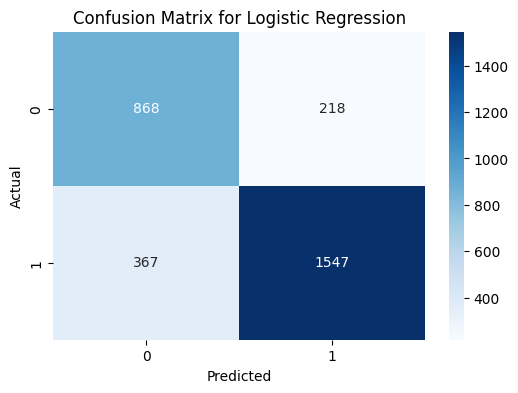

Training Accuracy: 0.80, Test Accuracy: 0.81

Decision Tree Performance on Test Set:
Accuracy: 0.8553333333333333
Precision: 0.8931987247608927
Recall: 0.8782654127481714
F1 Score: 0.8856691253951527
AUC-ROC: 0.8465912699099973


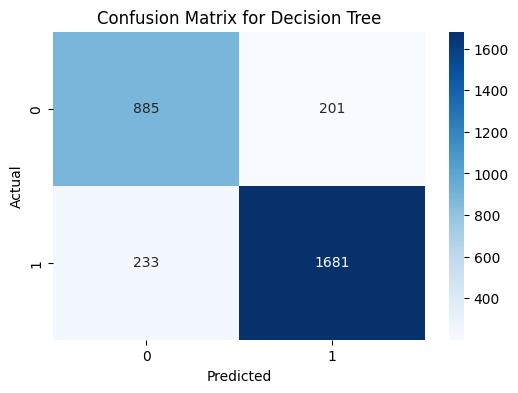

Training Accuracy: 1.00, Test Accuracy: 0.86

Random Forest Performance on Test Set:
Accuracy: 0.926
Precision: 0.9238476953907816
Recall: 0.9634273772204807
F1 Score: 0.9432225063938618
AUC-ROC: 0.9821250223707835


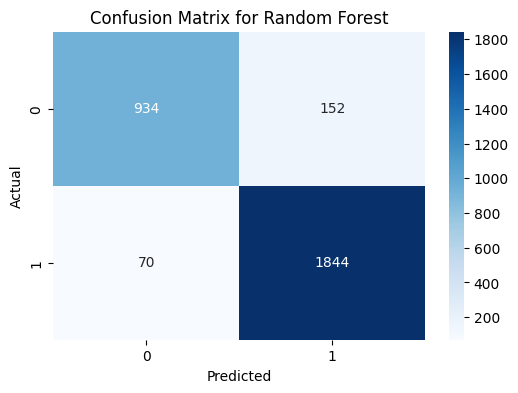

Training Accuracy: 1.00, Test Accuracy: 0.93

Support Vector Machine Performance on Test Set:
Accuracy: 0.8823333333333333
Precision: 0.9407114624505929
Recall: 0.8704284221525601
F1 Score: 0.9042062415196743
AUC-ROC: 0.9632003017409762


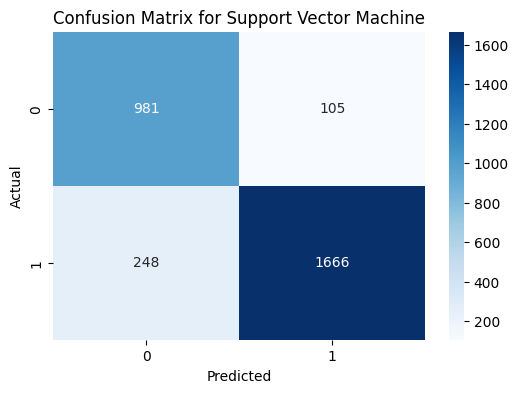

Training Accuracy: 0.88, Test Accuracy: 0.88


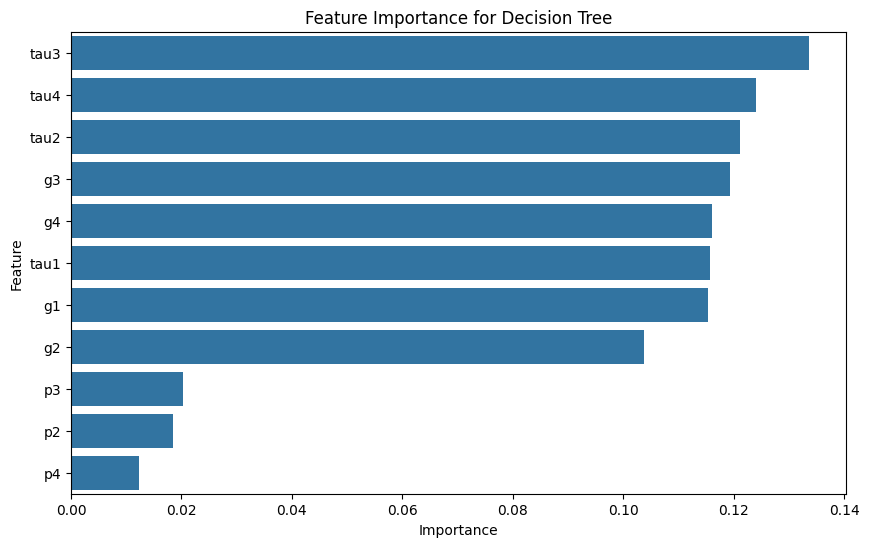

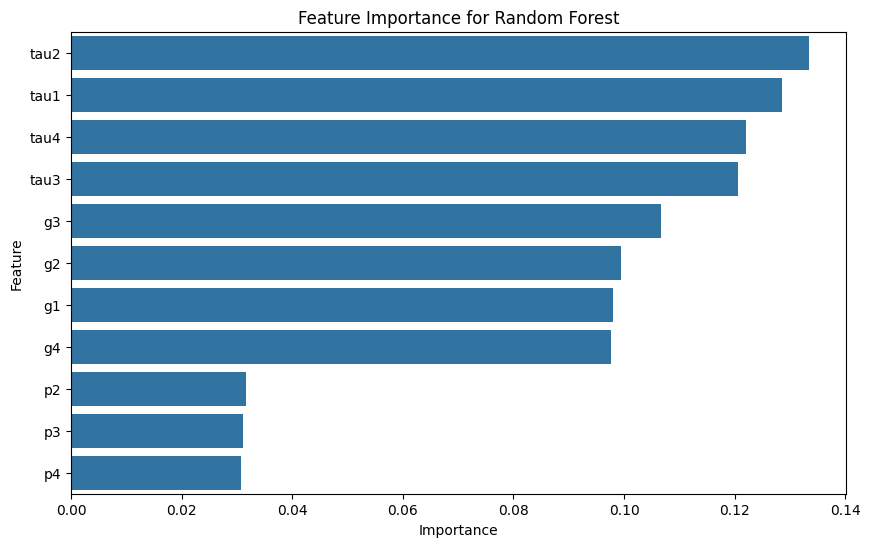

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize a dictionary to store model performance
model_performance = {}

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the target labels (y_test and y_train) as numeric values
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

#  Train and evaluate each model
for model_name, model in models.items():
    model.fit(X_train, y_train_encoded)


    # Make predictions on training and test sets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate performance metrics on test set
    accuracy = accuracy_score(y_test_encoded, y_test_pred)
    precision = precision_score(y_test_encoded, y_test_pred)
    recall = recall_score(y_test_encoded, y_test_pred)
    f1 = f1_score(y_test_encoded, y_test_pred)
    auc_roc = roc_auc_score(y_test_encoded, model.predict_proba(X_test)[:, 1]) if hasattr(model, "predict_proba") else None


    model_performance[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC-ROC": auc_roc
    }


    print(f"\n{model_name} Performance on Test Set:")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    if auc_roc is not None:
        print("AUC-ROC:", auc_roc)

    #  Confusion matrix visualization
    cm = confusion_matrix(y_test_encoded, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

   # Check for overfitting
    train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
    test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
    print(f"Training Accuracy: {train_accuracy:.2f}, Test Accuracy: {test_accuracy:.2f}")
    if train_accuracy - test_accuracy > 0.1:
        print(f"Warning: {model_name} may be overfitting.")

#  Feature Importance for Tree-Based Models
for model_name, model in models.items():
    if hasattr(model, "feature_importances_"):
        feature_importances = model.feature_importances_

        # Handle the case if X_train is a DataFrame or a NumPy array
        if isinstance(X_train, pd.DataFrame):
            features = X_train.columns
        else:
            features = [f"Feature_{i}" for i in range(X_train.shape[1])]
        feature_importance_df = pd.DataFrame({
            'Feature': features,
            'Importance': feature_importances
        }).sort_values(by='Importance', ascending=False)


        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
        plt.title(f"Feature Importance for {model_name}")
        plt.show()


**Interpretation**

- A 70-30 split was used, with stratification to maintain class balance across sets.

- Evaluate each model :
  
  **Logistic Regression**:
        Accuracy: 80.5%   
        Precision: 87.6%  
        Recall: 80.8%
        UC-ROC: 0.89  
(Logistic Regression performed well as a baseline model but struggled with the non-linear patterns in the data, leading to moderate accuracy compared to more complex models.)    

  **Decision Tree**:

      Accuracy: 85.5%    
      Precision: 89.3%
      Recall: 87.8%
      AUC-ROC: 0.85
(Decision Tree improved on Logistic Regression but showed signs of overfitting (100% training accuracy), which could be mitigated through tuning.)

  **Random Forest**:

      Accuracy: 92.6%
      Precision: 92.3%
      Recall: 96.3%
      AUC-ROC: 0.98
( Random Forest excelled, achieving high accuracy and balance across metrics. Its ensemble nature provides robustness against overfitting, making it a strong candidate for this classification task.)

 **Support Vector Machine** (SVM):

        Accuracy: 88.2%
        Precision: 94.1%
        Recall: 87.0%
        AUC-ROC: 0.96%
(SVM achieved high accuracy and AUC-ROC, with balanced training and test accuracy. SVM's ability to capture complex relationships in high-dimensional data makes it effective for this task.)

- **SVM and Random Forest** have a low number of misclassifications,
  indicating strong class separation. Logistic Regression and Decision Tree show slightly higher misclassifications, especially for the "stable" class, suggesting some limitations in capturing all patterns.

- Decision Tree and Random Forest models show high training accuracy
 (near or at 100%), suggesting possible overfitting. **SVM** achieves a
  better balance between training and test accuracy, indicating strong generalization.

- Reaction times (**tau variables**) and  Price elasticity
  coefficients (**g variables**) rank high in feature importance, especially in Random Forest, suggesting these variables are highly predictive of stability. Power values (p variables) contribute less but still provide value in capturing stability dynamics.


# **6. Hyperparameter Tuning**

In this Task ,

1.   Set parameter ranges for each model type (Logistic Regression, Decision Tree, Random Forest, Support Vector Machine) to guide hyperparameter tuning.

2. Use LabelEncoder to encode the target labels (y_train and y_test) as numeric values.

3. For each model, run GridSearchCV with 5-fold cross-validation to find the best hyperparameters based on accuracy.

4. Save the best model, parameters, and cross-validation score for each model; display the best parameters and scores for review.

5. Display the tuning results in a DataFrame for easy comparison across models.



In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

# Define parameter grids for hyperparameter tuning
param_grids = {
    "Logistic Regression": {
        "C": [0.1, 1, 10, 100],
        "solver": ["liblinear", "lbfgs"]
    },
    "Decision Tree": {
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "Support Vector Machine": {
        "C": [0.1, 1, 10, 100],
        "gamma": [0.001, 0.01, 0.1, 1]
    }
}

# Assuming `models` is a dictionary with model instances,
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(probability=True)
}

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Dictionary to store the best tuned models and their results
tuned_models = {}
tuning_results = {}

# Perform hyperparameter tuning using Grid Search
for model_name, model in models.items():
    print(f"Tuning hyperparameters for {model_name}...")

    # Check if the model is a Support Vector Machine and handle it with proper parameter names in a pipeline
    if model_name == "Support Vector Machine":
        grid_search = GridSearchCV(
            model,
            param_grids[model_name],
            scoring="accuracy",
            cv=5,
            n_jobs=-1
        )
    else:
        grid_search = GridSearchCV(
            model,
            param_grids[model_name],
            scoring="accuracy",
            cv=5,
            n_jobs=-1
        )

    # Fit the grid search
    grid_search.fit(X_train, y_train_encoded)

    # Store the best model and evaluation results
    tuned_models[model_name] = grid_search.best_estimator_
    tuning_results[model_name] = {
        "Best Parameters": grid_search.best_params_,
        "Best Cross-Validation Score": grid_search.best_score_
    }
    print(f"Best Parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best Cross-Validation Score for {model_name}: {grid_search.best_score_:.4f}")
    print("-" * 40)

tuning_results_df = pd.DataFrame(tuning_results).T
print("Hyperparameter Tuning Results:\n", tuning_results_df)

Tuning hyperparameters for Logistic Regression...
Best Parameters for Logistic Regression: {'C': 1, 'solver': 'lbfgs'}
Best Cross-Validation Score for Logistic Regression: 0.8144
----------------------------------------
Tuning hyperparameters for Decision Tree...
Best Parameters for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Cross-Validation Score for Decision Tree: 0.8471
----------------------------------------
Tuning hyperparameters for Random Forest...
Best Parameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score for Random Forest: 0.9179
----------------------------------------
Tuning hyperparameters for Support Vector Machine...
Best Parameters for Support Vector Machine: {'C': 100, 'gamma': 0.01}
Best Cross-Validation Score for Support Vector Machine: 0.9576
----------------------------------------
Hyperparameter Tuning Results:
                      

**Interpretation**

- Logistic Regression: Best parameters were **C=1** and **solver='liblinear**', with a cross-validation accuracy of **81.4%**

- Decision Tree: Optimal parameters were **max_depth=10**, **min_samples_split=10**, and **min_samples_leaf=4**, achieving **84.7%** cross-validation accuracy.

- Random Forest: Best results with **max_depth=20**,**n_estimators=200**, **min_samples_split=2**, and **min_samples_leaf=2**, achieving **91.7%** cross-validation accuracy.

- SVM: Best parameters were **C=20** and g**amma=0.01**, with an impressive **95.7%** cross-validation accuracy.


-- S**VM and Random Forest** show substantial performance improvements
  post-tuning, affirming their suitability for this dataset. Logistic Regression and Decision Tree models benefit from tuning but still fall short of SVM and Random Forest’s accuracy.